<a href="https://colab.research.google.com/github/naylaakas/PembelajaranMesin-2026/blob/main/JS04/Tugas_Praktikum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
# 1. Tugas K-Means

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans

df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


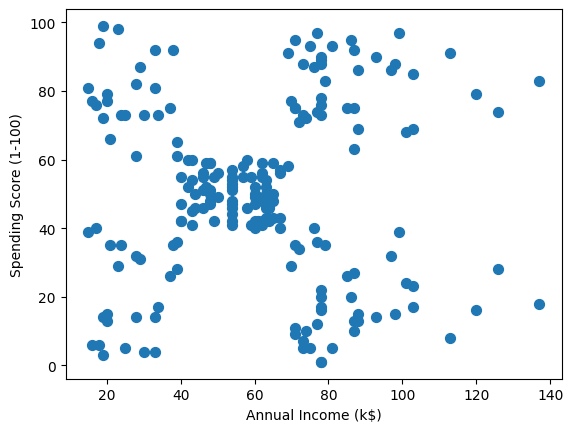

In [26]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]].values

plt.scatter(X[:, 0], X[:, 1], s=50)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

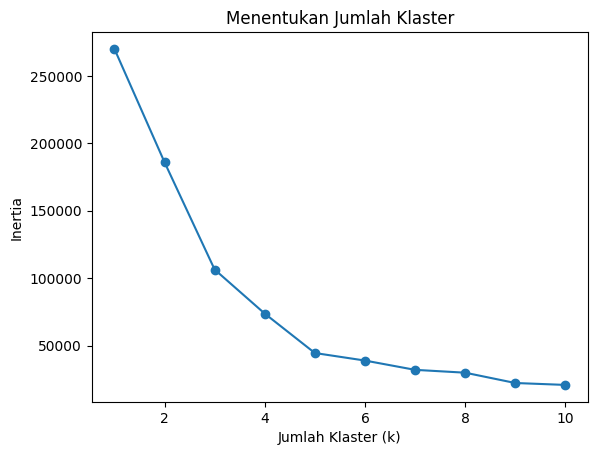

In [27]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("Jumlah Klaster (k)")
plt.ylabel("Inertia")
plt.title("Menentukan Jumlah Klaster")
plt.show()

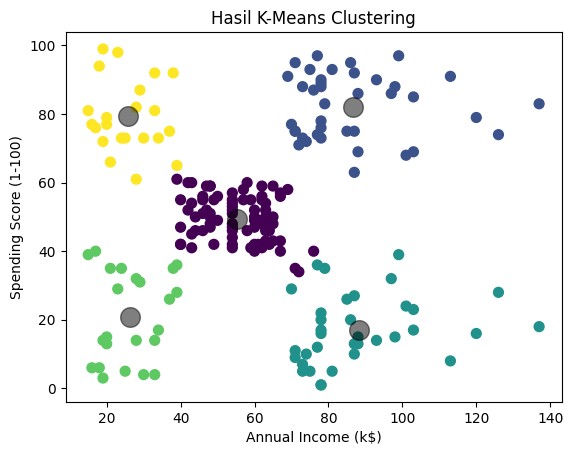

In [28]:
kmeans = KMeans(n_clusters=5, random_state=0)
kmeans.fit(X)

y_kmeans = kmeans.predict(X)

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y_kmeans,
    s=50,
    cmap='viridis'
)

centers = kmeans.cluster_centers_

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c='black',
    s=200,
    alpha=0.5
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Hasil K-Means Clustering")
plt.show()

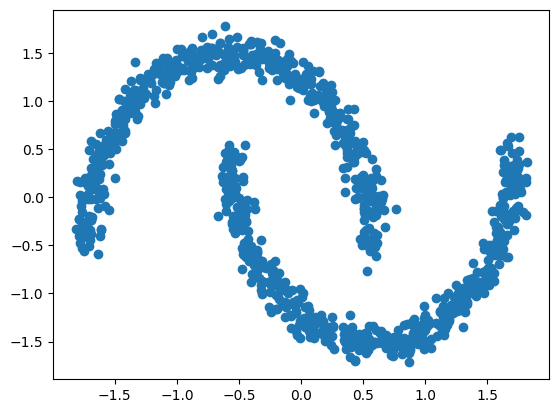

In [15]:
# 2. Tugas DBSCAN

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

X, labels_true = make_moons(
    n_samples=1000,
    noise=0.05,
    random_state=0
)

X = StandardScaler().fit_transform(X)

import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1])
plt.show()

In [16]:
import numpy as np

from sklearn import metrics
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.2, min_samples=5).fit(X)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 2
Estimated number of noise points: 0


In [17]:
print(f"Homogeneity: {metrics.homogeneity_score(labels_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(labels_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(labels_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(labels_true, labels):.3f}")
print(f"Adjusted Mutual Information: {metrics.adjusted_mutual_info_score(labels_true, labels):.3f}")
print(f"Silhouette Coefficient: {metrics.silhouette_score(X, labels):.3f}")

Homogeneity: 1.000
Completeness: 1.000
V-measure: 1.000
Adjusted Rand Index: 1.000
Adjusted Mutual Information: 1.000
Silhouette Coefficient: 0.392


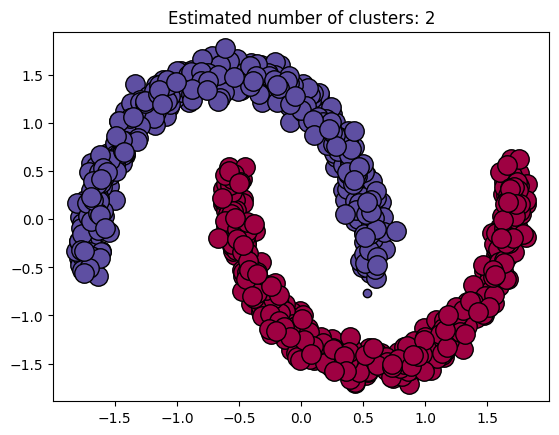

In [21]:
import matplotlib.pyplot as plt
import numpy as np

unique_labels = set(labels)

core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each)
          for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    # Core samples
    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    # Non-core samples
    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

In [22]:
results = []

eps_values = [0.05, 0.1, 0.3, 0.5]
min_samples_values = [3, 10, 20]

for eps in eps_values:
    for min_samples in min_samples_values:

        db = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = db.fit_predict(X)

        n_clusters = len(set(labels)) - (
            1 if -1 in labels else 0
        )

        n_noise = list(labels).count(-1)

        homogeneity = metrics.homogeneity_score(
            labels_true, labels
        )

        completeness = metrics.completeness_score(
            labels_true, labels
        )

        v_measure = metrics.v_measure_score(
            labels_true, labels
        )

        ari = metrics.adjusted_rand_score(
            labels_true, labels
        )

        ami = metrics.adjusted_mutual_info_score(
            labels_true, labels
        )

        mask = labels != -1

        if n_clusters > 1:
            silhouette = metrics.silhouette_score(
                X[mask],
                labels[mask]
            )
        else:
            silhouette = np.nan

        results.append([
            eps,
            min_samples,
            n_clusters,
            n_noise,
            homogeneity,
            completeness,
            v_measure,
            ari,
            ami,
            silhouette
        ])

In [23]:
#Tampilkan tabel

import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=[
        "eps",
        "min_samples",
        "clusters",
        "noise",
        "homogeneity",
        "completeness",
        "v_measure",
        "ARI",
        "AMI",
        "silhouette"
    ]
)

results_df

,eps,min_samples,clusters,noise,homogeneity,completeness,v_measure,ARI,AMI,silhouette
0,0.05,3,67,197,0.803825,0.154915,0.259767,0.032984,0.246428,0.323269
1,0.05,10,0,1000,0.000000,1.000000,0.000000,0.000000,0.000000,NaN
2,0.05,20,0,1000,0.000000,1.000000,0.000000,0.000000,0.000000,NaN
3,0.10,3,3,18,0.983471,0.708395,0.823571,0.854285,0.823246,0.178663
4,0.10,10,9,63,0.938949,0.358282,0.518656,0.435052,0.516899,0.243305
5,0.10,20,6,844,0.157108,0.153385,0.155224,0.010402,0.151519,0.799113
6,0.30,3,2,0,1.000000,1.000000,1.000000,1.000000,1.000000,0.391597
7,0.30,10,2,0,1.000000,1.000000,1.000000,1.000000,1.000000,0.391597
8,0.30,20,2,0,1.000000,1.000000,1.000000,1.000000,1.000000,0.391597
9,0.50,3,1,0,0.000000,1.000000,0.000000,0.000000,0.000000,NaN
